# DSxH 2526 Exercise: Prediction of Length Of Stay in ICU using MIMIC-IV

This notebook studies how the **Length of Stay (LOS) in the ICU** can be predicted using the **MIMIC-IV** Demo dataset. 

The severity of illness score OASIS can be used for this prediction, as well as other alternatives.

## MIMIC-IV Demo

The openly-available [MIMIC-IV Clinical Database Demo](https://physionet.org/content/mimic-iv-demo/2.2/) contains a subset of 100 patients of the original MIMIC-IV Database. The subset is randomly selected from the subset of patients in the dataset with an anchor_year_group value of 2011 - 2013 or 2014 - 2016 to ensure overlap with MIMIC-CXR v2.0.0.
For more information about MIMIC-IV, visit the [MIMIC MIT website](https://mimic.mit.edu/docs/iv/).

## OASIS

The Oxford Acute Severity of Illness Score (OASIS) is based on the following variables: age, elective surgery, prior length of stay (LOS) and seven physiologic measurements: Glasgow Coma Score (GCS), heart rate, mean arterial pressure (MAP), respiratory rate, temperature, urine output, ventilated. For each variable, the worst score across the first day in ICU should be used to tabulate OASIS.
For more information about OASIS visit [here](https://alistairewj.github.io/project/oasis/). 

## Preliminary questions

1.	Question 1. Compute:

    a.	the number of different patients in the dataset 

    b.	the number of different hospital admissions in the dataset 
    
    c.	the number of different ICU stays in the dataset 

2.	Question 2. Explain the difference between 'intime' from ICUSTAYS table and 'admittime' from ADMISSIONS table.



## Tasks

The main task is to predict if the Length of Stay (LOS) of a patient in the ICU is short or long using two different strategies: 

(1) using the severity of illness score OASIS of the fisrt 24/48 hours of an ICU stay.

(2) using the values of some variables of the first hours of the stay in the ICU.

The information of LOS is included in ICUSTAY table of MIMIC-IV and is measured in fractional days. 

To simplfy the problem, we can convert this information into binary labels by using a threshold of 4 days. Less than 4 days is a “short stay”, otherwise is a “long stay”:

-	LOS < 4: short stay

-	Otherwise: long stay.


## Summary of the solution:

The solution of this task has 3 phases:

1. Extract Transform Phase

    The following variables have to be computed: age, pre-LOS, elective surgery, Glasgow Coma Score (GCS), heart rate, mean arterial pressure (MAP), respiratory rate, temperature, urine output, ventilated; and saved in separate csv files.


2. Analysis Phase:

- PREDICTION USING OASIS

    Once you have computed the necessary variables you can merge them into a single dataframe to pass it to the OASIS function provided in GitHub and compute the severity score using all the instances of the first 24 hours (and also 48 hours).
    You can filter the instances to keep the ones of the first 24 hours (or 48 hours) as observations to compute the OASIS score. 

    In addition, we propose a modification of OASIS computation motivated for the following issues: 
    As can be seen in the code to compute OASIS, the score is NaN if any of the considered variables has all its instances as NaN. MIMIC has many NaN values and the demo subset is more limited in the number. So, the number of samples with OASIS different of NaNs considering first 24h is small. You can use the first 48h, but the number is also very limited and the performance of the proposed classifier can be poor. 
    We propose to try an alternative to compute the OASIS score. You can change the original code to consider the variable as 0.0 (state in normal range) when all instances of the variable are NaN. For that use **`np.nansum`** instead of using sum in the line:

    **`oasis_score = sum([oasis_prelos, oasis_age, oasis_gcs, oasis_hr, oasis_map, oasis_resp,oasis_temp, oasis_urine, oasis_vent, oasis_surg]).`** 

    In summary, you must develop the following different alternatives:
    -	Original OASIS within first 48h, 
    -	Modification of OASIS within first 24h
    -	Modification of OASIS within first 48h

    Posed question: Compute and show the number of NaN values of OASIS for the three different alternatives (Original OASIS with 48h, Modification of OASIS with 24h and 48h).

- PREDICTION USING VALUES OF VARIABLES

    Instead of using OASIS score, use available variables in the classification model learning a multidimensional decision boundary.

- ALTERNATIVE: PREDICTION USING VALUES OF VARIABLES

3.	Conclusions. 

    Extract some conclusions after comparison of the results of the different approaches. Use tables to summarize.

## Development:
Before starting, download the MIMIC-IV Clinical Database Demo and copy the folder in a folder called 'data'.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

%matplotlib inline

In [2]:
# --- Data Loading ---

# Directories
DATA_DIR = Path("./data/mimic-iv-clinical-database-demo-2.2/")

# ICUSTAYS Table
# contains the information for ICU stays including admission and discharge times 
df_icustays = pd.read_csv(DATA_DIR / "icu/icustays.csv.gz")
df_icustays = df_icustays.sort_values(by=["subject_id"])

# ADMISSIONS Table
# gives information regarding a patient’s admission to the hospital
df_admissions = pd.read_csv(DATA_DIR / "hosp/admissions.csv.gz")
df_admissions = df_admissions.sort_values(by=["subject_id"])

In [3]:
df_admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
104,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
105,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
103,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
18,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
157,10001217,27703517,2157-12-18 16:58:00,2157-12-24 14:55:00,NaN,DIRECT EMER.,P99698,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,?,MARRIED,WHITE,NaN,NaN,0


In [4]:
df_icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
44,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
66,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
83,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113
130,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1.338588
62,10002428,23473524,35479615,Surgical Intensive Care Unit (SICU),Medical Intensive Care Unit (MICU),2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222


## Preliminary Questions

In [5]:
# -- Code to answer the questions here --

# To complete 

# 1. Compute the number of different patients in the dataset
num_patients = df_icustays["subject_id"].nunique()
print(f"Number of different patients: {num_patients}")

# 2. Compute the number of different hospital admissions in the dataset
num_admissions = df_icustays["hadm_id"].nunique()
print(f"Number of different hospital admissions: {num_admissions}")

# 3. Compute the number of different ICU stays in the dataset
num_icu_stays = df_icustays["stay_id"].nunique()
print(f"Number of different ICU stays: {num_icu_stays}")

Number of different patients: 100
Number of different hospital admissions: 128
Number of different ICU stays: 140


**Include the answers to the questions in the separate report document.** 


## Task 1

Predict if the length of stay (LOS) of the ICU patients is "short" or "long" (binary classification problem) based on the severity score OASIS of: 

(1) the fisrt 24 hours of an ICU stay and 

(2) the fisrt 48 hours of an ICU stay.

Instructions for the exercise:
The solution of this exercise has 3 phases:
1. Extract Transform Phase
2. Analysis
3. Conclusions




## [Task 1] Phase 1: Extract Transform

We provide you the code to compute all the needed variables (except temperature, which you should complete the code) and save them in csv files.


In [6]:
# --- More Data Loading ---

# Directories
DATA_DIR = Path("./data/mimic-iv-clinical-database-demo-2.2/")
OUT_DIR = Path("./data/output/")

# PATIENTS Table
df_patients = pd.read_csv(DATA_DIR / "hosp/patients.csv.gz")
df_patients = df_patients.sort_values(by=["subject_id"])

# CHARTEVENTS Table
df_chartevents = pd.read_csv(DATA_DIR / "icu/chartevents.csv.gz")
df_chartevents = df_chartevents.sort_values(by=["subject_id"])

# PROCEDUREEVENTS Table
df_procedureevents = pd.read_csv(DATA_DIR / "icu/procedureevents.csv.gz")
df_procedureevents = df_procedureevents.sort_values(by=["subject_id"])

# OUTPUTEVENTS Table
df_outputevents = pd.read_csv(DATA_DIR / "icu/outputevents.csv.gz")
df_outputevents = df_outputevents.sort_values(by=["subject_id"])

# D_ITEMS Table
df_d_items = pd.read_csv(DATA_DIR / "icu" / "d_items.csv.gz")
df_d_items = df_d_items.sort_values(by=["itemid"])

In [7]:
df_chartevents.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
492906,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,2180-07-23 14:20:00,223761,98.7,98.7,°F,0.0
492957,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,2180-07-23 17:03:00,224642,Oral,NaN,NaN,0.0
492951,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,2180-07-23 17:01:00,220277,95,95.0,%,0.0
492950,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,2180-07-23 17:01:00,220180,58,58.0,mmHg,0.0
492949,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,2180-07-23 17:42:00,227969,Items within reach,NaN,NaN,0.0


#### 1. Age

In [8]:
# --- Age ----
df_age = df_icustays.copy()

# Merge with df_patients to get anchor_age and anchor_year
df_age = df_age.merge(df_patients[["subject_id", "anchor_age", "anchor_year"]], on="subject_id", how="left")

# Calculate age at ICU admission as anchor_age + (icu_admit_year - anchor_year)
df_age["icu_admit_year"] = pd.to_datetime(df_age["intime"]).dt.year
df_age["age"] = df_age["anchor_age"] + (df_age["icu_admit_year"] - df_age["anchor_year"])

# Select necessary columns
df_age = df_age[["subject_id", "hadm_id", "stay_id", "intime", "age"]]

# Display the first 5 rows
# display(df_age.head())

# Save the dataframe
df_age.to_csv(OUT_DIR / "age.csv", index=False)

#### 2. Pre-LOS

In [9]:
# --- pre-LOS ---
df_prelos = df_icustays.copy()

# Merge with df_admissions to get admittime
df_prelos = df_prelos.merge(df_admissions[["subject_id", "hadm_id", "admittime"]], on=["subject_id", "hadm_id"], how="left")

# Calculate pre-LOS as the difference between intime and admittime in hours
df_prelos["intime"] = pd.to_datetime(df_prelos["intime"])
df_prelos["admittime"] = pd.to_datetime(df_prelos["admittime"])
df_prelos["pre_los"] = (df_prelos["intime"] - df_prelos["admittime"]).dt.total_seconds() / 3600.

# Select necessary columns
df_prelos = df_prelos[["subject_id", "hadm_id", "stay_id", "admittime", "intime", "pre_los"]]

# Display the first 5 rows
# display(df_prelos.head())

# Save the dataframe
df_prelos.to_csv(OUT_DIR / "pre_los.csv", index=False)

#### 3. Elective Surgery

In [10]:
# --- Elective Surgery ---
df_elective_surgery = df_admissions.copy()

# Merge with df_icustays to get stay_id
df_elective_surgery = df_elective_surgery.merge(df_icustays[["subject_id", "hadm_id", "stay_id"]], on=["subject_id", "hadm_id"], how="left")

# Select necessary columns
df_elective_surgery = df_elective_surgery[["subject_id", "hadm_id", "stay_id", "admittime", "admission_type"]]

# Display the first 5 rows
# display(df_elective_surgery.head())

# Rename admission_type categories to match OASIS function
df_elective_surgery["admission_type"] = df_elective_surgery["admission_type"].map({
    "EW EMER.": "emergency",
    "DIRECT EMER.": "emergency",
    "URGENT": "urgent",
    "SURGICAL SAME DAY ADMISSION": "elective",
    "OBSERVATION ADMIT": "elective",
    "ELECTIVE": "elective",
    "EU OBSERVATION": "elective",
    "DIRECT OBSERVATION": "elective",
    "AMBULATORY OBSERVATION": "elective",
})

# Drop rows with missing stay_id
df_elective_surgery = df_elective_surgery.dropna(subset=["stay_id"])

# Save the dataframe
df_elective_surgery.to_csv(OUT_DIR / "elective_surgery.csv", index=False)

#### 4. Temperature

In [11]:
# --- Temperature ---
df_temperature = df_chartevents.copy()


In [12]:
# Complete the code:
# Use d_items table to consult the itemid for the temperature measures.
df_d_items = pd.read_csv(DATA_DIR / "icu/d_items.csv.gz")

# Extract the itemids for temperature from d_items
temperature_itemids = df_d_items[df_d_items['label'].str.contains('temperature', case=False, na=False)]['itemid'].tolist()
df_temperature = df_chartevents[
    df_chartevents["itemid"].isin(temperature_itemids)
].copy()

In [13]:
#  Convert the "Temperature Fahrenheit" measurements to Celsius. The itemid for "Temperature Fahrenheit"

df_temperature["temperature_celsius"] = np.where(df_temperature["itemid"] == 223761, (df_temperature["valuenum"] - 32) * 5 / 9, df_temperature["valuenum"])

# Select necessary columns
df_temperature = df_temperature[["subject_id", "hadm_id", "stay_id", "charttime", "temperature_celsius"]]

# Merge with df_icustays to include intime
df_temperature = df_temperature.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_temperature = df_temperature[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "temperature_celsius"]]

# Normalize the time measurements to hours
df_temperature["intime"] = pd.to_datetime(df_temperature["intime"])
df_temperature["charttime"] = pd.to_datetime(df_temperature["charttime"])
df_temperature["temperature_time"] = (df_temperature["charttime"] - df_temperature["intime"]).dt.total_seconds() / 3600.
df_temperature = df_temperature[["subject_id", "hadm_id", "stay_id", "temperature_time", "temperature_celsius"]]

# Display the first 5 rows
display(df_temperature.head())

# Save the dataframe
df_temperature.to_csv(OUT_DIR / "temperature.csv", index=False)

,subject_id,hadm_id,stay_id,temperature_time,temperature_celsius
0,10000032,29079034,39553978,0.000000,37.055556
1,10000032,29079034,39553978,3.000000,NaN
2,10000032,29079034,39553978,0.000000,NaN
3,10000032,29079034,39553978,0.766667,NaN
4,10000032,29079034,39553978,7.233333,NaN


#### 5. Heart Rate, Respiratory Rate, Mean Arterial Pressure (MAP)

In [14]:
# --- Heart Rate ---
df_heartrate = df_chartevents.copy()

heartrate_items = df_d_items[df_d_items["label"].str.contains("Heart Rate", case=False, na=False, regex=False)][["itemid", "label"]]
# display(heartrate_items)

# As can be seen in the output, we are interested in the following itemid:
#   220045: Heart Rate

heartrate_ids = heartrate_items[heartrate_items["label"].isin(["Heart Rate"])]["itemid"].to_numpy()
print(heartrate_ids)
# display(heartrate_ids)

# Now, we filter the df_heartrate dataframe to only include the itemid's of interest
df_heartrate = df_heartrate[df_heartrate["itemid"] == int(220045)]
display(df_heartrate.head())

# Select necessary columns
df_heartrate = df_heartrate[["subject_id", "hadm_id", "stay_id", "charttime", "valuenum"]]
df_heartrate.rename(columns={"valuenum": "heartrate"}, inplace=True)
df_heartrate = df_heartrate[["subject_id", "hadm_id", "stay_id", "charttime", "heartrate"]]

# Merge with df_icustays to include intime
df_heartrate = df_heartrate.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_heartrate = df_heartrate[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "heartrate"]]

# Normalize the time measurements to hours
df_heartrate["intime"] = pd.to_datetime(df_heartrate["intime"])
df_heartrate["charttime"] = pd.to_datetime(df_heartrate["charttime"])
df_heartrate["heartrate_time"] = (df_heartrate["charttime"] - df_heartrate["intime"]).dt.total_seconds() / 3600.
df_heartrate = df_heartrate[["subject_id", "hadm_id", "stay_id", "heartrate_time", "heartrate"]]

# Display the first 5 rows
# display(df_heartrate.head())

# Save the dataframe
df_heartrate.to_csv(OUT_DIR / "heartrate.csv", index=False)

[220045]


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
493275,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,2180-07-23 14:43:00,220045,93,93.0,bpm,0.0
493098,10000032,29079034,39553978,88981.0,2180-07-23 14:12:00,2180-07-23 14:17:00,220045,91,91.0,bpm,0.0
493044,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,2180-07-23 22:15:00,220045,94,94.0,bpm,0.0
493028,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,2180-07-23 21:01:00,220045,94,94.0,bpm,0.0
492991,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,2180-07-23 21:01:00,220045,100,100.0,bpm,0.0


In [15]:
# --- Respiratory Rate ---
df_resprate = df_chartevents.copy()

resprate_items = df_d_items[df_d_items["label"].str.contains("Respiratory Rate", case=False, na=False, regex=False)][["itemid", "label"]]
# display(resprate_items)

# As can be seen in the output, we are interested in the following itemid:
#   220210: Respiratory Rate

resprate_ids = resprate_items[resprate_items["label"].isin(["Respiratory Rate"])]["itemid"].to_numpy()
# display(resprate_ids)

# Now, we filter the df_resprate dataframe to only include the itemid's of interest
df_resprate = df_resprate[df_resprate["itemid"].isin(resprate_ids)]
# display(df_resprate.head())

# Select necessary columns
df_resprate = df_resprate[["subject_id", "hadm_id", "stay_id", "charttime", "valuenum"]]
df_resprate.rename(columns={"valuenum": "resprate"}, inplace=True)
df_resprate = df_resprate[["subject_id", "hadm_id", "stay_id", "charttime", "resprate"]]

# Merge with df_icustays to include intime
df_resprate = df_resprate.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_resprate = df_resprate[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "resprate"]]

# Normalize the time measurements to hours
df_resprate["intime"] = pd.to_datetime(df_resprate["intime"])
df_resprate["charttime"] = pd.to_datetime(df_resprate["charttime"])
df_resprate["resprate_time"] = (df_resprate["charttime"] - df_resprate["intime"]).dt.total_seconds() / 3600.
df_resprate = df_resprate[["subject_id", "hadm_id", "stay_id", "resprate_time", "resprate"]]

# Display the first 5 rows
# display(df_resprate.head())

# Save the dataframe
df_resprate.to_csv(OUT_DIR / "resprate.csv", index=False)

In [16]:
# --- Mean Arterial Pressure (MAP) ---
df_map = df_chartevents.copy()

map_items = df_d_items[df_d_items["label"].str.contains("Arterial", case=False, na=False, regex=False)][["itemid", "label"]]
# display(map_items)

# As can be seen in the output, we are interested in the following itemid:
#   220052: Arterial Blood Pressure mean

map_ids = map_items[map_items["label"].isin(["Arterial Blood Pressure mean"])]["itemid"].to_numpy()
# display(map_ids)

# Now, we filter the df_map dataframe to only include the itemid's of interest
df_map = df_map[df_map["itemid"].isin(map_ids)]
# display(df_map.head())

# Select necessary columns
df_map = df_map[["subject_id", "hadm_id", "stay_id", "charttime", "valuenum"]]
df_map.rename(columns={"valuenum": "map"}, inplace=True)
df_map = df_map[["subject_id", "hadm_id", "stay_id", "charttime", "map"]]

# Merge with df_icustays to include intime
df_map = df_map.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_map = df_map[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "map"]]

# Normalize the time measurements to hours
df_map["intime"] = pd.to_datetime(df_map["intime"])
df_map["charttime"] = pd.to_datetime(df_map["charttime"])
df_map["map_time"] = (df_map["charttime"] - df_map["intime"]).dt.total_seconds() / 3600.
df_map = df_map[["subject_id", "hadm_id", "stay_id", "map_time", "map"]]

# Display the first 5 rows
# display(df_map.head())

# Save the dataframe
df_map.to_csv(OUT_DIR / "map.csv", index=False)

#### 6. Glasgow Coma Scale (GCS)

In [17]:
# --- GCS ---
df_gcs = df_chartevents.copy()

gcs_items = df_d_items[df_d_items["label"].str.contains("GCS", case=False, na=False, regex=False)][["itemid", "label"]]
# display(gcs_items)

# As can be seen in the output, we are interested in the following itemid's:
#   220739: GCS - Eye Opening
#   223900: GCS - Verbal Response
#   223901: GCS - Motor Response

gcs_ids = gcs_items[gcs_items["label"].isin(["GCS - Eye Opening", "GCS - Verbal Response", "GCS - Motor Response"])]["itemid"].to_numpy()
# display(gcs_ids)

# Now, we filter the df_gcs dataframe to only include the itemids of interest
df_gcs = df_gcs[df_gcs["itemid"].isin(gcs_ids)]
# display(df_gcs.head())

# Pivot the dataframe to have one row per charttime and columns for each GCS component
df_gcs_pivot = df_gcs.pivot_table(index=["subject_id", "hadm_id", "stay_id", "charttime"], columns="itemid", values="valuenum").reset_index()

# display(df_gcs_pivot.head())
# Rename columns for clarity
df_gcs_pivot.rename(columns={220739: "gcs_eye", 223900: "gcs_verbal", 223901: "gcs_motor"}, inplace=True)

# Calculate total GCS score (sum of each component)
df_gcs_pivot["gcs_total"] = df_gcs_pivot["gcs_eye"] + df_gcs_pivot["gcs_verbal"] + df_gcs_pivot["gcs_motor"]

# Merge back to the original dataframe
df_gcs = df_gcs.merge(df_gcs_pivot[["subject_id", "hadm_id", "stay_id", "charttime", "gcs_total"]], on=["subject_id", "hadm_id", "stay_id", "charttime"], how="left")

# Select necessary columns
df_gcs = df_gcs[["subject_id", "hadm_id", "stay_id", "charttime", "gcs_total"]]

# Merge with df_icustays to include intime
df_gcs = df_gcs.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_gcs = df_gcs[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "gcs_total"]]

# Normalize the time measurements to hours
df_gcs["intime"] = pd.to_datetime(df_gcs["intime"])
df_gcs["charttime"] = pd.to_datetime(df_gcs["charttime"])
df_gcs["gcs_time"] = (df_gcs["charttime"] - df_gcs["intime"]).dt.total_seconds() / 3600.
df_gcs = df_gcs[["subject_id", "hadm_id", "stay_id", "gcs_time", "gcs_total"]]

# Display the first 5 rows
# display(df_gcs.head())

# Save the dataframe
df_gcs.to_csv(OUT_DIR / "gcs.csv", index=False)


#### 7. Urine

In [18]:
# --- Urine ---
df_urine = df_outputevents.copy()

urine_items = df_d_items[df_d_items["label"].str.contains("Urine|Foley", case=False, na=False, regex=True)][["itemid", "label"]]
# display(urine_items)

# As can be seen in the output, we are interested in the following itemid:
#   226559: Foley
#   226627: OR Urine
#   226631: PACU Urine

urine_ids = urine_items[urine_items["label"].isin(["Foley", "OR Urine", "PACU Urine"])]["itemid"].to_numpy()
# urine_ids = urine_items[urine_items["label"].isin(["Foley"])]["itemid"].to_numpy()
# display(urine_ids)

# Now, we filter the df_urine dataframe to only include the itemid's of interest
df_urine = df_urine[df_urine["itemid"].isin(urine_ids)]
# display(df_urine.head())

# Select necessary columns
df_urine = df_urine[["subject_id", "hadm_id", "stay_id", "charttime", "value"]]
df_urine.rename(columns={"value": "urine"}, inplace=True)
df_urine = df_urine[["subject_id", "hadm_id", "stay_id", "charttime", "urine"]]

# Merge with df_icustays to include intime
df_urine = df_urine.merge(df_icustays[["subject_id", "hadm_id", "stay_id", "intime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")
df_urine = df_urine[["subject_id", "hadm_id", "stay_id", "intime", "charttime", "urine"]]

# Normalize the time measurements to hours
df_urine["intime"] = pd.to_datetime(df_urine["intime"])
df_urine["charttime"] = pd.to_datetime(df_urine["charttime"])
df_urine["urine_time"] = (df_urine["charttime"] - df_urine["intime"]).dt.total_seconds() / 3600.
df_urine = df_urine[["subject_id", "hadm_id", "stay_id", "urine_time", "urine"]]

# Display the first 5 rows
# display(df_urine.head())

# Save the dataframe
df_urine.to_csv(OUT_DIR / "urine.csv", index=False)
df_outputevents

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valueuom
5327,10000032,29079034,39553978,88981,2180-07-23 15:00:00,2180-07-23 16:00:00,226560,175,ml
5603,10001217,24597018,37067082,71578,2157-11-21 00:42:00,2157-11-21 00:43:00,226560,300,ml
6287,10001217,24597018,37067082,57256,2157-11-21 10:00:00,2157-11-21 10:26:00,226560,450,ml
1211,10001217,27703517,34592300,69406,2157-12-20 11:00:00,2157-12-20 11:36:00,226560,500,ml
1530,10001217,27703517,34592300,18215,2157-12-19 23:00:00,2157-12-19 23:36:00,226560,900,ml
...,...,...,...,...,...,...,...,...,...
8996,10040025,27996267,36107367,84976,2148-01-29 10:00:00,2148-01-29 11:33:00,226559,100,ml
8995,10040025,27996267,36107367,84976,2148-01-29 18:14:00,2148-01-29 18:15:00,226580,200,ml
8994,10040025,27996267,36107367,84976,2148-01-29 17:00:00,2148-01-29 18:16:00,226559,100,ml
8993,10040025,27996267,36107367,84976,2148-01-29 11:00:00,2148-01-29 11:33:00,226559,125,ml


#### 8. Ventilation

In [19]:
# --- Ventilation ---
df_ventilation = df_procedureevents.copy()

ventilation_items = df_d_items[df_d_items["label"].str.contains("Ventilation", case=False, na=False, regex=False)][["itemid", "label"]]
# display(ventilation_items)

# As can be seen in the output, we are interested in the following itemid:
#   225792: Invasive Ventilation
#   225794: Non-invasive Ventilation

ventilation_ids = ventilation_items[ventilation_items["label"].isin(["Invasive Ventilation", "Non-invasive Ventilation"])]["itemid"].to_numpy()
# display(ventilation_ids)

# Now, we filter the df_ventilation dataframe to only include the itemid's of interest
df_ventilation = df_ventilation[df_ventilation["itemid"].isin(ventilation_ids)]
# display(df_ventilation.head())

# Create a new column `ventilation` with default value `n`
df_ventilated = df_icustays.copy()
df_ventilated["ventilation"] = "n"

# Add the starttime of ventilation to df_ventilated
df_ventilated = df_ventilated.merge(df_ventilation.drop_duplicates(subset=["subject_id", "hadm_id", "stay_id"])[["subject_id", "hadm_id", "stay_id", "starttime"]], on=["subject_id", "hadm_id", "stay_id"], how="left")

# Update the `ventilation` column to `y` for patients who have either invasive or non-invasive ventilation
ventilated_patients = df_ventilation["subject_id"].unique()
df_ventilated.loc[df_ventilated["subject_id"].isin(ventilated_patients), "ventilation"] = "y"


# Normalize the time measurements to hours since intime
df_ventilated["intime"] = pd.to_datetime(df_ventilated["intime"])
df_ventilated["starttime"] = pd.to_datetime(df_ventilated["starttime"])
df_ventilated["ventilation_time"] = (df_ventilated["starttime"] - df_ventilated["intime"]).dt.total_seconds() / 3600.
df_ventilated = df_ventilated[["subject_id", "hadm_id", "stay_id", "intime", "ventilation_time", "ventilation"]]

# Display the first 5 rows
# display(df_ventilated.head())

# Save the dataframe
df_ventilated.to_csv(OUT_DIR / "ventilation.csv", index=False)

#### Target Variables

Here, we also save a dataframe containing the LOS for each ICU stay for each patient.

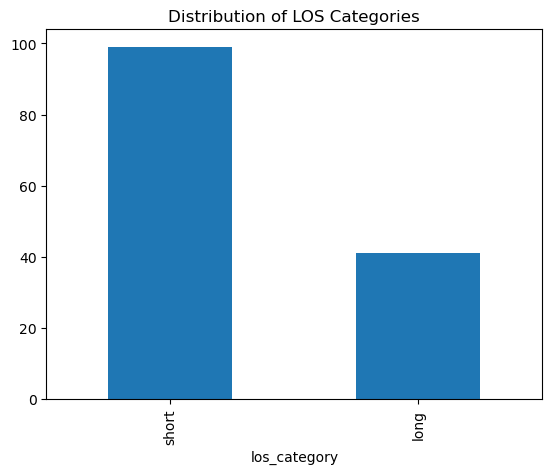

In [20]:
# --- LOS ---
df_los = df_icustays.copy()
df_los = df_los[["subject_id", "hadm_id", "stay_id", "intime", "outtime", "los"]]

df_los["los_category"] = np.where(df_los["los"] <= 4, "short", "long")

df_los.to_csv(OUT_DIR / "los.csv", index=False)

df_los["los_category"].value_counts().plot(kind="bar", title="Distribution of LOS Categories")

plt.show()



## [Task 1] Phase 2: Analysis

### 1. Prediction using OASIS

In [21]:
# Copy the code of the oasis function for the OASIS score calculation in a separate file called oasis.py
# We can import the function here:
from oasis import compute_oasis

In [33]:
# Function to create a merged dataframe for a given stay_id and hours
def merge_by_icustay(df_age,
                      df_prelos,
                      df_elective_surgery,
                      df_temperature,
                      df_heartrate,
                      df_resprate,
                      df_map,
                      df_gcs,
                      df_urine,
                      df_ventilated,
                      stay_id,
                      hours):
    df_merged = df_age[df_age["stay_id"] == stay_id].copy()

    df_merged = df_merged.merge(df_prelos[df_prelos["stay_id"] == stay_id], on=["subject_id", "hadm_id", "stay_id"], how="outer")

    df_merged = df_merged.merge(df_elective_surgery[df_elective_surgery["stay_id"] == stay_id], on=["subject_id", "hadm_id", "stay_id"], how="outer")

    df_temperature_stay_hours = df_temperature[(df_temperature["stay_id"] == stay_id) & (df_temperature["temperature_time"] <= hours)]
    df_merged = pd.concat([df_merged, df_temperature_stay_hours], axis=0, ignore_index=True)

    df_heartrate_stay_hours = df_heartrate[(df_heartrate["stay_id"] == stay_id) & (df_heartrate["heartrate_time"] <= hours)]
    df_merged = pd.concat([df_merged, df_heartrate_stay_hours], axis=0, ignore_index=True)

    df_resprate_stay_hours = df_resprate[(df_resprate["stay_id"] == stay_id) & (df_resprate["resprate_time"] <= hours)]
    df_merged = pd.concat([df_merged, df_resprate_stay_hours], axis=0, ignore_index=True)

    df_map_stay_hours = df_map[(df_map["stay_id"] == stay_id) & (df_map["map_time"] <= hours)]
    df_merged = pd.concat([df_merged, df_map_stay_hours], axis=0, ignore_index=True)

    df_gcs_stay_hours = df_gcs[(df_gcs["stay_id"] == stay_id) & (df_gcs["gcs_time"] <= hours)]
    df_gcs_stay_hours = df_gcs_stay_hours.groupby(["subject_id", "hadm_id", "stay_id"]).min().reset_index()
    df_merged = pd.concat([df_merged, df_gcs_stay_hours], axis=0, ignore_index=True)

    df_urine_stay_hours = df_urine[(df_urine["stay_id"] == stay_id) & (df_urine["urine_time"] <= hours)]
    df_urine_stay_hours = df_urine_stay_hours.groupby(["subject_id", "hadm_id", "stay_id"]).sum().reset_index()
    df_merged = pd.concat([df_merged, df_urine_stay_hours], axis=0, ignore_index=True)

    df_merged = pd.concat([df_merged, df_ventilated[df_ventilated["stay_id"] == stay_id]], axis=0, ignore_index=True)

    df_merged.rename(columns={
        "age": "age",
        "pre_los": "prelos",
        "admission_type": "admission_type",
        "temperature_celsius": "temp_c",
        "heartrate": "hrate",
        "resprate": "resp_rate",
        "map": "MAP",
        "gcs_total": "GCS_total",
        "urine": "urine",
        "ventilation": "ventilated"
    }, inplace=True)

    return df_merged
    

In [34]:
# We need to merge the following dataframes to calculate the OASIS score
df_age = pd.read_csv(OUT_DIR / "age.csv")[["subject_id", "hadm_id", "stay_id", "age"]]
df_prelos = pd.read_csv(OUT_DIR / "pre_los.csv")[["subject_id", "hadm_id", "stay_id", "pre_los"]]
df_elective_surgery = pd.read_csv(OUT_DIR / "elective_surgery.csv")[["subject_id", "hadm_id", "stay_id", "admission_type"]]
df_temperature = pd.read_csv(OUT_DIR / "temperature.csv")[["subject_id", "hadm_id", "stay_id", "temperature_time", "temperature_celsius"]]
df_heartrate = pd.read_csv(OUT_DIR / "heartrate.csv")[["subject_id", "hadm_id", "stay_id", "heartrate_time", "heartrate"]]
df_resprate = pd.read_csv(OUT_DIR / "resprate.csv")[["subject_id", "hadm_id", "stay_id", "resprate_time", "resprate"]]
df_map = pd.read_csv(OUT_DIR / "map.csv")[["subject_id", "hadm_id", "stay_id", "map_time", "map"]]
df_gcs = pd.read_csv(OUT_DIR / "gcs.csv")[["subject_id", "hadm_id", "stay_id", "gcs_time", "gcs_total"]]
df_urine = pd.read_csv(OUT_DIR / "urine.csv")[["subject_id", "hadm_id", "stay_id", "urine_time", "urine"]]
df_ventilated = pd.read_csv(OUT_DIR / "ventilation.csv")[[ "subject_id", "hadm_id", "stay_id", "ventilation_time", "ventilation"]]


In [35]:
df_los = pd.read_csv(OUT_DIR / "los.csv").drop(columns=["intime", "outtime"])
# Create a dataframe to store the OASIS scores and LOS
for stay_id in df_los["stay_id"].unique():
    df_merged_24 = merge_by_icustay(df_age,
                                  df_prelos,
                                  df_elective_surgery,
                                  df_temperature,
                                  df_heartrate,
                                  df_resprate,
                                  df_map,
                                  df_gcs,
                                  df_urine,
                                  df_ventilated,
                                  stay_id,
                                  24)

    df_merged_48 = merge_by_icustay(df_age,
                                  df_prelos,
                                  df_elective_surgery,
                                  df_temperature,
                                  df_heartrate,
                                  df_resprate,
                                  df_map,
                                  df_gcs,
                                  df_urine,
                                  df_ventilated,
                                  stay_id,
                                  48)

    oasis_48_nan = compute_oasis(df_merged_48, allow_nan=True)
    df_los.loc[df_los["stay_id"] == stay_id, "oasis_48_nan"] = oasis_48_nan

    oasis_24_no_nan = compute_oasis(df_merged_24, allow_nan=False)
    df_los.loc[df_los["stay_id"] == stay_id, "oasis_24_no_nan"] = oasis_24_no_nan

    oasis_48_no_nan = compute_oasis(df_merged_48, allow_nan=False)
    df_los.loc[df_los["stay_id"] == stay_id, "oasis_48_no_nan"] = oasis_48_no_nan



Compute and show the number of NaN values of OASIS for the three different approaches (Original OASIS with 48h, Modification of OASIS with 24h and 48h).

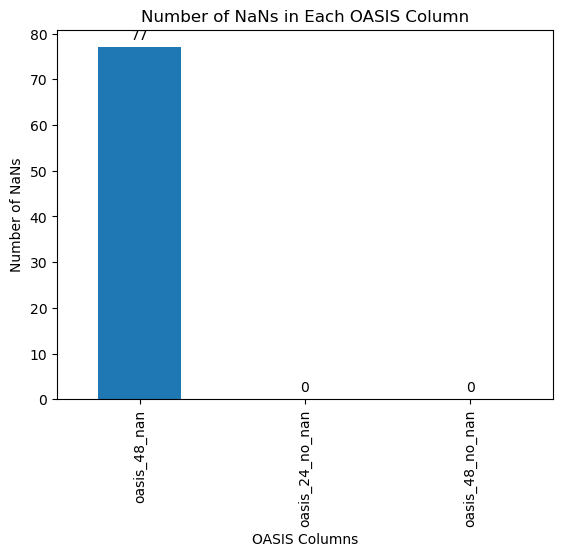

In [36]:
# Count the number of NaNs in each OASIS column
nan_counts = df_los[["oasis_48_nan", "oasis_24_no_nan", "oasis_48_no_nan"]].isna().sum()

# Plot the number of NaNs
nan_counts.plot(kind="bar", title="Number of NaNs in Each OASIS Column")
for i, v in enumerate(nan_counts):
    plt.text(i, v + 1, str(v), ha="center", va="bottom")
plt.xlabel("OASIS Columns")
plt.ylabel("Number of NaNs")
plt.show()


**Question:** 
Discuss the results of this plot.

To complete in the separete report document.




#### Prediction using original OASIS 48h

Let us first plot a boxplot of the value of original OASIS 48h (NaN) depending on the binary length of stay (short/long).

Independent t-test p-value: 8.81e-04


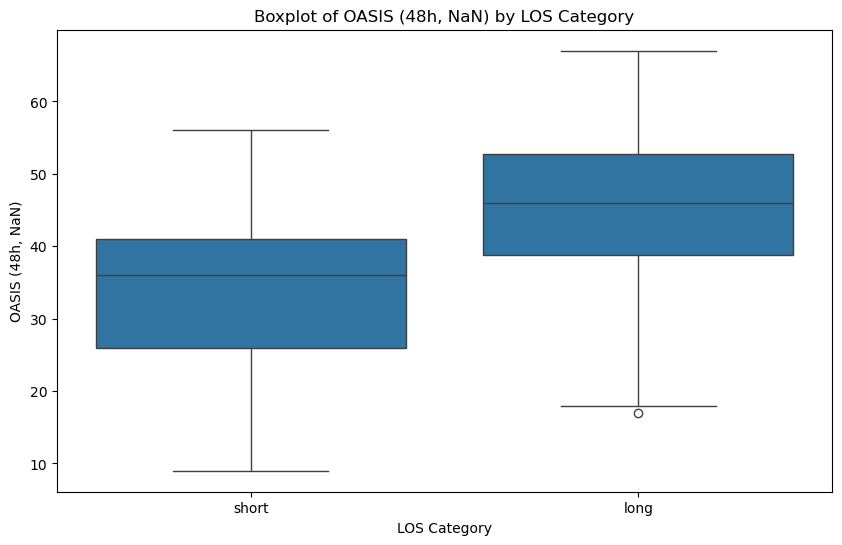

In [27]:

import seaborn as sns
from scipy.stats import ttest_ind

# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="los_category", y="oasis_48_nan", data=df_los)
plt.title("Boxplot of OASIS (48h, NaN) by LOS Category")
plt.xlabel("LOS Category")
plt.ylabel("OASIS (48h, NaN)")

# Check for stastical significance
short_los = df_los[df_los["los_category"] == "short"]["oasis_48_nan"]
long_los = df_los[df_los["los_category"] == "long"]["oasis_48_nan"]

_, p_value = ttest_ind(short_los, long_los, nan_policy="omit")
print(f"Independent t-test p-value: {p_value:.2e}")

plt.show()

We can see that there are statistically significant differences between the two groups, hence, it makes sense to develop a classifier.

We will use a logistic regression classifier, since we are dealing only with two groups and a single feature.

Average accuracy: 0.73


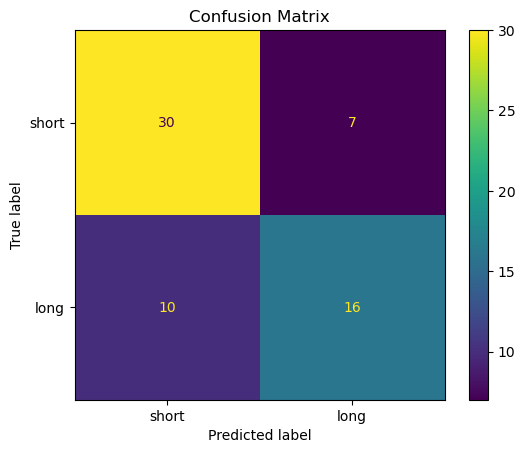

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Drop rows with NaNs
df_los1 = df_los.dropna(subset=["oasis_48_nan"])

# Define the features and target
X = df_los1[["oasis_48_nan"]]
y = df_los1["los_category"]

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Cross-validation loop
accuracies =[]

confusion_matrices =[]

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["short", "long"])
    confusion_matrices.append(cm)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.2f}")

# Print overall confusion matrix
cm = np.sum(confusion_matrices, axis=0)
ConfusionMatrixDisplay(cm, display_labels=["short", "long"]).plot()
plt.title("Confusion Matrix")
plt.show()

#### Prediction using modified OASIS 24h

Let us first plot a boxplot of the value of OASIS 24h no NaN depending on the binary length of stay (short/long).

Independent t-test p-value: 9.71e-08


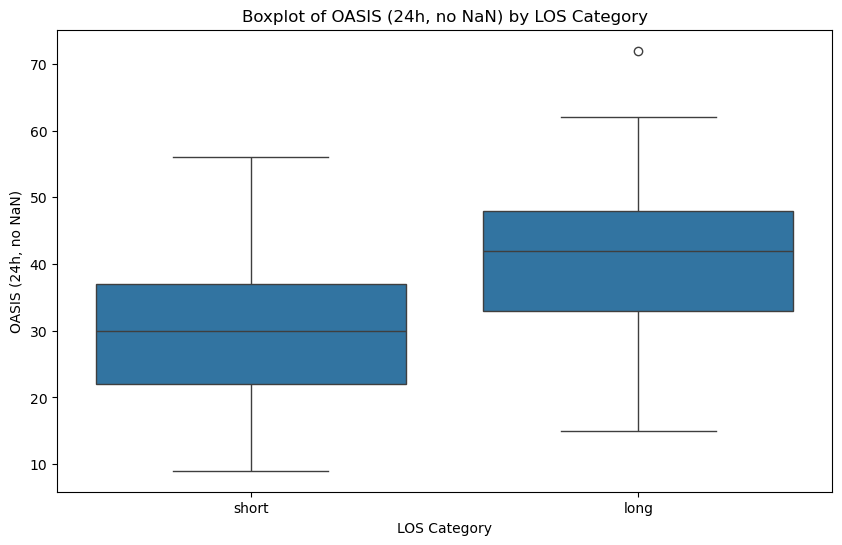

In [38]:
import seaborn as sns
from scipy.stats import ttest_ind

# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="los_category", y="oasis_24_no_nan", data=df_los)
plt.title("Boxplot of OASIS (24h, no NaN) by LOS Category")
plt.xlabel("LOS Category")
plt.ylabel("OASIS (24h, no NaN)")

# Check for stastical significance
short_los = df_los[df_los["los_category"] == "short"]["oasis_24_no_nan"]
long_los = df_los[df_los["los_category"] == "long"]["oasis_24_no_nan"]

_,  p_value = ttest_ind(short_los, long_los, nan_policy="omit")
print(f"Independent t-test p-value: {p_value:.2e}")

plt.show()


We can see that there are statistically significant differences between the two groups, hence, it makes sense to develop a classifier.

We will use a logistic regression classifier, since we are dealing only with two groups and a single feature.

Average accuracy: 0.77


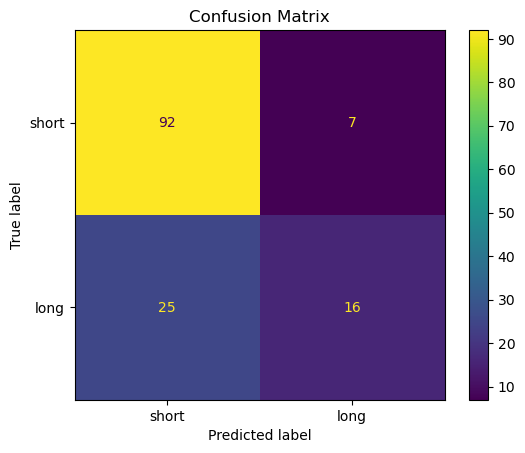

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# Define the features and target
X = df_los[["oasis_24_no_nan"]]
y = df_los["los_category"]

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Cross-validation loop
accuracies = []

confusion_matrices = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["short", "long"])
    confusion_matrices.append(cm)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.2f}")

# Print overall confusion matrix
cm = np.sum(confusion_matrices, axis=0)
ConfusionMatrixDisplay(cm, display_labels=["short", "long"]).plot()
plt.title("Confusion Matrix")
plt.show()

#### Prediction using modified OASIS 48h

Let us first plot a boxplot of the value of OASIS 24h no NaN depending on the binary length of stay (short/long).

Independent t-test p-value: 7.15e-09


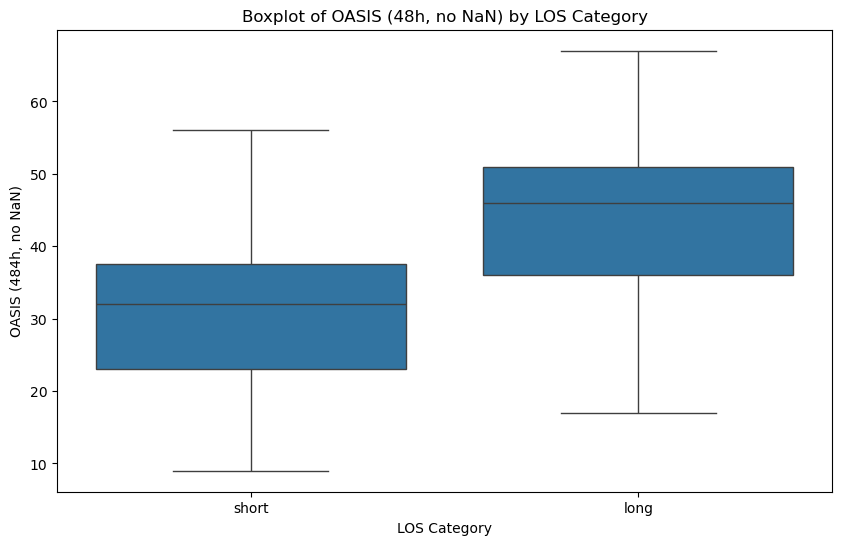

In [40]:
import seaborn as sns
from scipy.stats import ttest_ind

# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="los_category", y="oasis_48_no_nan", data=df_los)
plt.title("Boxplot of OASIS (48h, no NaN) by LOS Category")
plt.xlabel("LOS Category")
plt.ylabel("OASIS (484h, no NaN)")

# Check for stastical significance
short_los = df_los[df_los["los_category"] == "short"]["oasis_48_no_nan"]
long_los = df_los[df_los["los_category"] == "long"]["oasis_48_no_nan"]

_,  p_value = ttest_ind(short_los, long_los, nan_policy="omit")
print(f"Independent t-test p-value: {p_value:.2e}")

plt.show()

We can see that there are statistically significant differences between the two groups, hence, it makes sense to develop a classifier.

We will use a logistic regression classifier, since we are dealing only with two groups and a single feature.

Average accuracy: 0.79


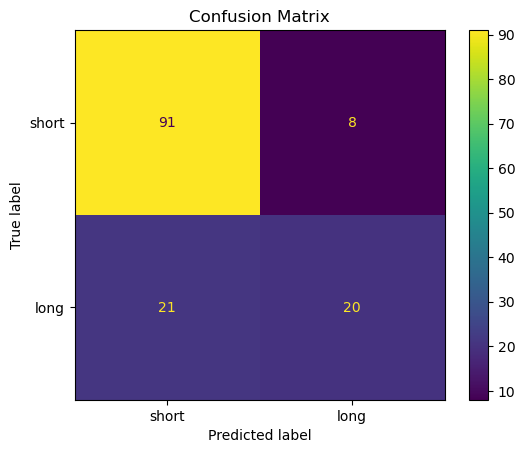

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# Define the features and target
X = df_los[["oasis_48_no_nan"]]
y = df_los["los_category"]

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Cross-validation loop
accuracies = []

confusion_matrices = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["short", "long"])
    confusion_matrices.append(cm)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.2f}")

# Print overall confusion matrix
cm = np.sum(confusion_matrices, axis=0)
ConfusionMatrixDisplay(cm, display_labels=["short", "long"]).plot()
plt.title("Confusion Matrix")
plt.show()


## [Task 1] Phase 3: Extract conclusions comparing the different models.

To complete in the separete report document.


## Task 2.

The objective is the same, to predict if the Length of Stay (LOS) of a patient in the ICU is short or long, but using an alternative to OASIS.

## [Task 2] Phase 1: Prediction using Values of Variables

Here, instead of predicting the LOS using the OASIS score, we will use the values of the variables themselves. 

To simplify the problem and to be able to solve it in reasonable time with the available computational resources, instead of using the whole temporal series of each variable as feature, we can compute the mean of the first 48h of stay.

First of all, we will build our dataset.

In [42]:
df_los = pd.read_csv(OUT_DIR / "los.csv")
df_merged = pd.DataFrame(index=df_los["stay_id"].unique(),
                         columns=["age", "pre_los", "admission_type", "temp_c", "hrate", "resp_rate", "MAP", "GCS_total", "urine", "ventilated"])
df_merged.index.name = "stay_id"

df_merged["age"] = df_age.groupby("stay_id")["age"].first()
df_merged["pre_los"] = df_prelos.groupby("stay_id")["pre_los"].first()
df_merged["admission_type"] = df_elective_surgery.groupby("stay_id")["admission_type"].first()
df_merged["temp_c"] = df_temperature[df_temperature["temperature_time"] <= 48].groupby("stay_id")["temperature_celsius"].mean()
df_merged["hrate"] = df_heartrate[df_heartrate["heartrate_time"] <= 48].groupby("stay_id")["heartrate"].mean()
df_merged["resp_rate"] = df_resprate[df_resprate["resprate_time"] <= 48].groupby("stay_id")["resprate"].mean()
df_merged["MAP"] = df_map[df_map["map_time"] <= 48].groupby("stay_id")["map"].mean()
df_merged["GCS_total"] = df_gcs[df_gcs["gcs_time"] <= 48].groupby("stay_id")["gcs_total"].min()
df_merged["urine"] = df_urine[df_urine["urine_time"] <= 48].groupby("stay_id")["urine"].sum()
df_merged["ventilated"] = df_ventilated.groupby("stay_id")["ventilation"].first()

Let us analyze the number of NaN's in each column

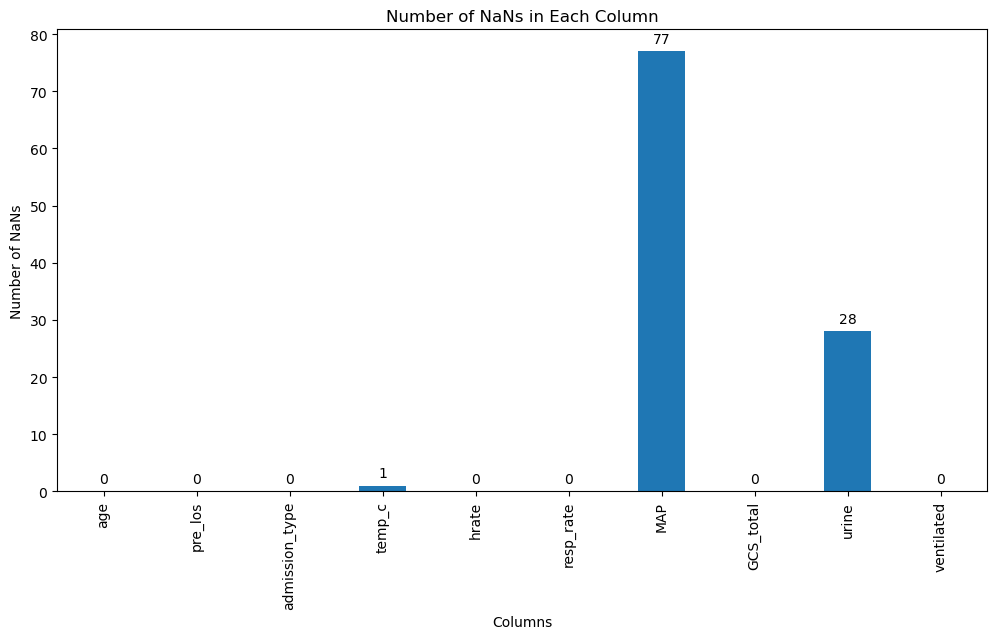

In [43]:
# Count the number of NaNs in each column
nan_counts = df_merged.isna().sum()

# Plot the number of NaNs
plt.figure(figsize=(12, 6))
nan_counts.plot(kind="bar", title="Number of NaNs in Each Column")
for i, v in enumerate(nan_counts):
    plt.text(i, v + 1, str(v), ha="center", va="bottom")
plt.xlabel("Columns")
plt.ylabel("Number of NaNs")
plt.show()

The most reasonable thing is to drop the `MAP` and `urine` columns and to drop the instance with `temp_c` NaN.

In [44]:
df_merged = df_merged.drop(columns=["MAP", "urine"])
df_merged = df_merged.dropna(subset=["temp_c"])

Now, we will prepare the dataset for the classification task.

In [45]:
# One-hot encode the column `admission_type`
df_merged = pd.get_dummies(df_merged, columns=["admission_type"], drop_first=False)

# One-hot encode the column `ventilated`
df_merged["ventilated"] = df_merged["ventilated"].map({"n": 0, "y": 1})

## [Task 2] Phase 2: Analysis


Let us now implement a Random Forest Classifier.

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Merge with LOS to get the target
df_merged = df_merged.merge(df_los[["stay_id", "los_category"]], on="stay_id", how="left")

X = df_merged.drop(columns=["stay_id", "los_category"])
y = df_merged["los_category"]


Average accuracy: 0.73


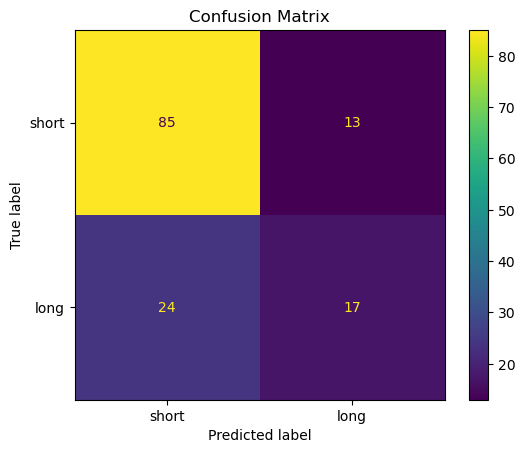

In [47]:
from sklearn.model_selection import GridSearchCV

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Cross-validation loop
accuracies = []
confusion_matrices = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    RFmodel = RandomForestClassifier()

    # Hyperparameter Tuning
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
    grid_search = GridSearchCV(estimator=RFmodel, param_grid=param_grid, cv=3, n_jobs=-1, verbose=0)

    grid_search.fit(X_train, y_train)

    # Get the best estimator
    RFmodel = grid_search.best_estimator_
    RFmodel.fit(X_train, y_train)

    # Predict
    y_pred = RFmodel.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["short", "long"])
    confusion_matrices.append(cm)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.2f}")

# Print overall confusion matrix
cm = np.sum(confusion_matrices, axis=0)
ConfusionMatrixDisplay(cm, display_labels=["short", "long"]).plot()
plt.title("Confusion Matrix")
plt.show()

## [Task 2] Phase 3: Extract conclusions comparing the different models.

To complete in the separete report document.


## [Task 3] Phase 1: Try to improve the performance.

Starting ideas:

- All classifiers show a pronouced bias towards predicting the majority class, something that limits their performance and could be attributed to the fact that we are dealing with a heavily unbalanced dataset. Could you try a "weighted" model using the parameter class_weight in the function RandomForestClassifier? Compute accuracy and recall to see the effect.
  
- Lower performance of the classifier using variable values could be attributed to the fact that it uses aggregations instead of the full time series. Could you look for an alternative?


In [ ]:
# To complete the code here


## [Task 3] Phase 3: Extract conclusions comparing the different models.

To complete in the separete report document.